
# Assignment 1: Understanding Generative and Discriminative Models Using MNIST

## Objective

The objective of this assignment is to understand the basic difference between a discriminative model and a generative model by working with a simple dataset of handwritten digits.

In this notebook, the MNIST dataset is used with only the digits **0 and 1**. A discriminative model is trained to classify the digits, while a simple autoencoder is used as a generative model to learn patterns in the digit images and produce digit-like examples.

### Models Used
- **Discriminative Model:** Logistic Regression
- **Generative Model:** Simple Autoencoder


## 1. Import Required Libraries

In [1]:

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)


## 2. Load the MNIST Dataset

MNIST contains handwritten digit images of size 28 × 28 pixels. We will keep only the images representing **0 and 1**.

In [ ]:

(x_train_full, y_train_full), (x_test_full, y_test_full) = mnist.load_data()


train_mask = (y_train_full == 0) | (y_train_full == 1)
test_mask = (y_test_full == 0) | (y_test_full == 1)

x_train = x_train_full[train_mask]
y_train = y_train_full[train_mask]

x_test = x_test_full[test_mask]
y_test = y_test_full[test_mask]

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)
Training labels: (12665,)
Testing labels: (2115,)


## 3. Visualize Some Real MNIST Images

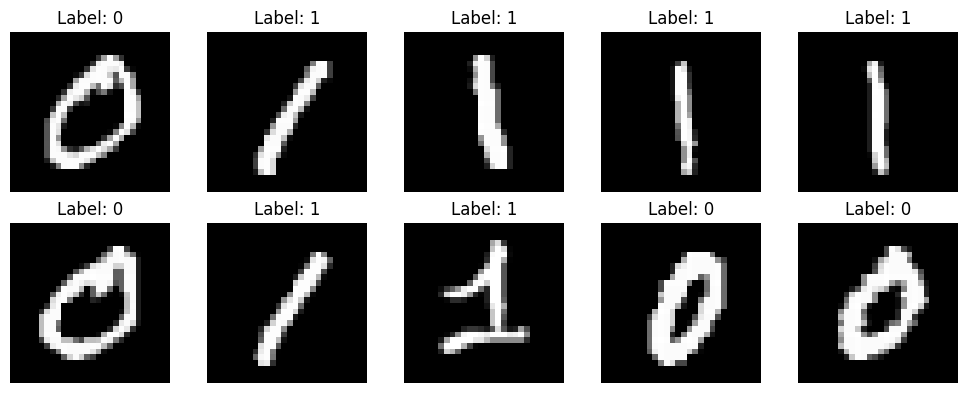

In [ ]:

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()



## 4. Prepare the Data

The pixel values in MNIST range from 0 to 255. We normalize them to a range of 0 to 1.

For Logistic Regression, each 28 × 28 image is flattened into a vector of 784 pixels.


In [ ]:

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0


x_train_flat = x_train_norm.reshape(len(x_train_norm), 28 * 28)
x_test_flat = x_test_norm.reshape(len(x_test_norm), 28 * 28)

print("Flattened training shape:", x_train_flat.shape)
print("Flattened testing shape:", x_test_flat.shape)


Flattened training shape: (12665, 784)
Flattened testing shape: (2115, 784)



## 5. Discriminative Model - Logistic Regression

A discriminative model learns how to distinguish between classes. Here, Logistic Regression learns to decide whether an input image is a **0 or a 1**.

The model focuses on the relationship between the input image and its label rather than trying to generate new images.


In [ ]:


discriminative_model = LogisticRegression(max_iter=1000, random_state=42)

discriminative_model.fit(x_train_flat, y_train)

y_pred = discriminative_model.predict(x_test_flat)


accuracy = accuracy_score(y_test, y_pred)

print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Digit 0", "Digit 1"]))


Discriminative Model Accuracy: 99.95%

Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00       980
     Digit 1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



## 6. Visualize Discriminative Model Predictions

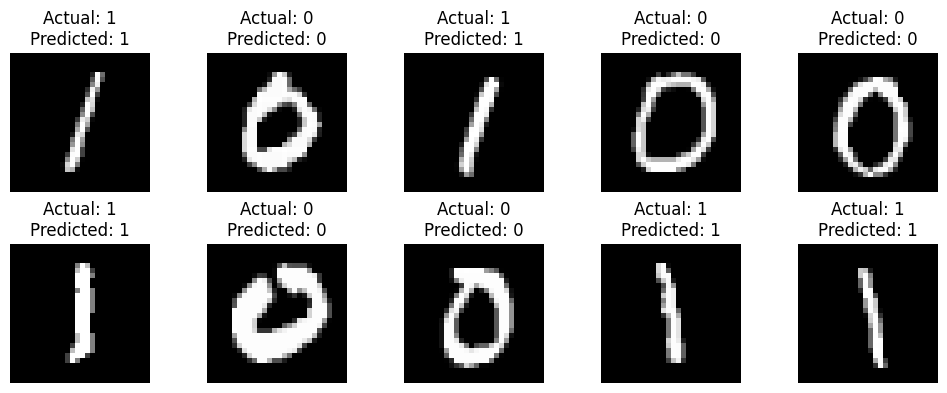

In [ ]:

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()



## 7. Generative Model - Simple Autoencoder

An autoencoder is a neural network that learns to compress an image into a smaller representation and then reconstruct the image.

For this assignment, the autoencoder learns the patterns found in the 0 and 1 images. After training, we can use the decoder to create digit-like images from points in its learned latent space.


In [ ]:


autoencoder_train = x_train_norm.reshape(-1, 28 * 28)


input_dim = 784
latent_dim = 32

encoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(latent_dim, activation="relu")
], name="encoder")

decoder = models.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid")
], name="decoder")

autoencoder_input = layers.Input(shape=(input_dim,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = models.Model(autoencoder_input, decoded, name="autoencoder")

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the Autoencoder

In [ ]:

history = autoencoder.fit(
    autoencoder_train,
    autoencoder_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.2643 - val_loss: 0.1487
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1340 - val_loss: 0.1216
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1155 - val_loss: 0.1093
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1040 - val_loss: 0.0994
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0960 - val_loss: 0.0934
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0910 - val_loss: 0.0897
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0874 - val_loss: 0.0861
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0843 - val_loss: 0.0840
Epoch 9/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0822 - val_loss: 0.0815
Epoch 10/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0803 - val_loss: 0.0827


## 9. Training Loss

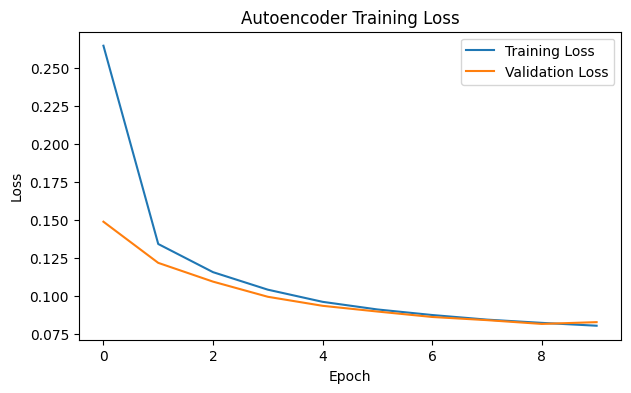

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()


## 10. Reconstruct Real Images

The autoencoder receives real images and attempts to reconstruct them. This shows how well it learned the patterns in the dataset.

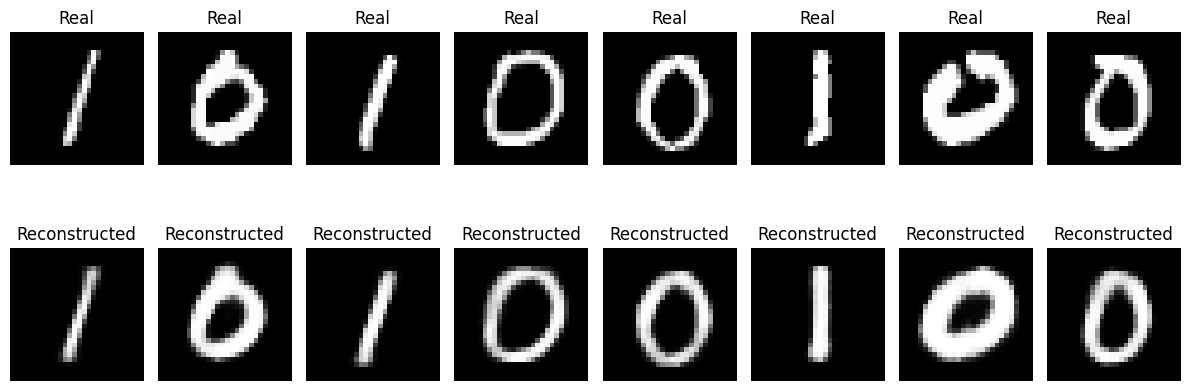

In [ ]:

test_flat = x_test_norm.reshape(-1, 784)
reconstructed = autoencoder.predict(test_flat, verbose=0)

plt.figure(figsize=(12, 5))

for i in range(8):

    plt.subplot(2, 8, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("Real")
    plt.axis("off")

    plt.subplot(2, 8, i + 9)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()



## 11. Generate New Digit-Like Examples

The decoder can take points from the latent space and turn them into images. The following examples are generated by sampling random latent vectors.

Because this is a simple autoencoder, the generated images are not expected to be perfect. The purpose is to demonstrate the idea of learning image patterns and producing new digit-like examples.


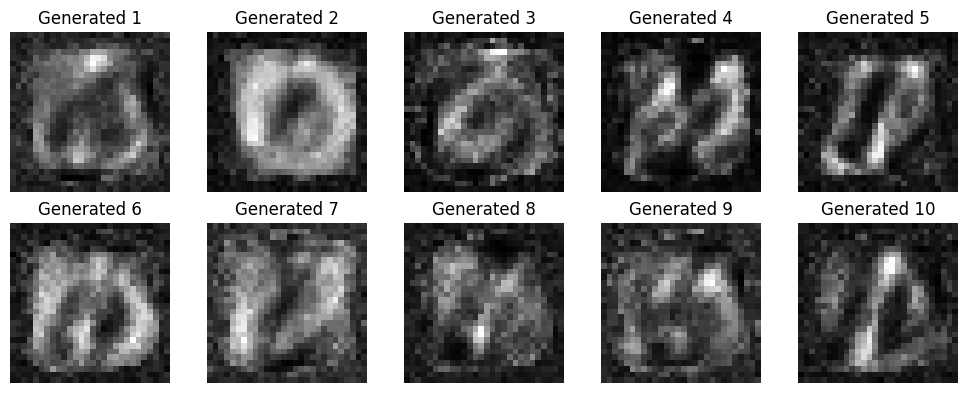

In [ ]:


num_generated = 10

random_latent_vectors = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=(num_generated, latent_dim)
)

generated_images = decoder.predict(random_latent_vectors, verbose=0)

plt.figure(figsize=(10, 4))

for i in range(num_generated):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.title(f"Generated {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()



## 12. Visual Comparison: Real, Predicted and Generated Images

The following visualization compares:
- Real MNIST images
- Predictions made by the discriminative model
- New images produced through the generative model


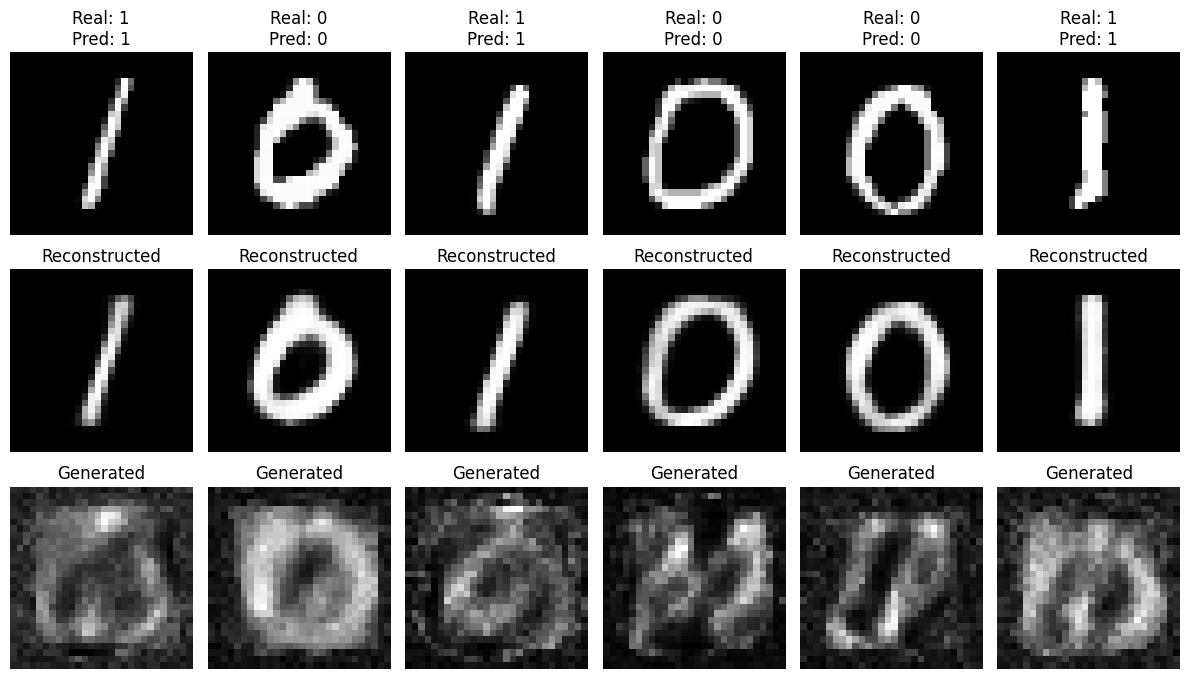

In [ ]:

plt.figure(figsize=(12, 7))

for i in range(6):
    plt.subplot(3, 6, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"Real: {y_test[i]}\nPred: {y_pred[i]}")
    plt.axis("off")

for i in range(6):
    plt.subplot(3, 6, i + 7)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")


for i in range(6):
    plt.subplot(3, 6, i + 13)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()



## 13. Comparison of the Two Approaches

### Discriminative Model

The Logistic Regression model learns to distinguish between the two classes, 0 and 1. Its main goal is classification. It learns patterns that help it make a decision about which class an input image belongs to.

### Generative Model

The Autoencoder learns the underlying patterns present in the digit images. Instead of only predicting a class label, it learns a compressed representation and reconstructs images. Its decoder can also produce new digit-like examples from latent vectors.

### Key Difference

The main difference is that the discriminative approach focuses on **making a decision between classes**, while the generative approach focuses on **learning patterns in the data and producing or reconstructing examples**.



## 14. Conclusion

In this assignment, MNIST images containing only digits 0 and 1 were used to understand the difference between discriminative and generative models. Logistic Regression was used as the discriminative model and achieved a measurable classification accuracy on the test data. A simple Autoencoder was used as the generative model to learn patterns in the digit images, reconstruct them, and generate new digit-like examples.

The experiment demonstrates that the two approaches have different objectives. The discriminative model is mainly concerned with identifying the correct class, while the generative model learns characteristics of the input data so that it can reconstruct or generate examples. This provides a basic understanding of the difference between learning a decision boundary and learning a data distribution.
